In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.graphics.gofplots import qqplot
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import train_test_split, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler


`mi_county_info.csv`

FIPS = Federal Information Processing Series. Unique 5 digit ID (leading zeroes dropped).

Population = 2024 est

area= land area in sq miles 

peninsula. Upper Peninsula (UP) or Lower Peninsula (LP)

ECO Region. Michigan Dept of Natural Resources designation. NLP = Northern Lower Peninsula. SLP = Southern Lower Peninsula. UP = Upper Peninsula.

Area = further subdivision of eco region area. WUP = Western UP. EUP = Eastern UP. NELP = North Eastern LP. NWLP = North Western LP. SELP = South Eastern LP. SWLP = South Western LP. SBLP = Saginaw Bay LP. SCLP = South Central LP. 

---

`land_cover.csv`
11_pct: Open Waters
21_pct: Developed, Open Spaces
22_pct:
23_pct:
24_pct:
31_pct:
41_pct:
42_pct:
43_pct:
52_pct:
71_pct:
81_pct:
82_pct:
90_pct: 
95_pct:
250_pct:

---
`deer_harvest.csv`

Antlered = mature males with antlers

Antlerless = females or immature males

---

`deer_crash.csv`

- county/crashes
---

`vehicle_miles.csv`

**LS-1: State Trunkline**
The State Trunkline System consists of roads, streets, and highways found both inside and outside the limits of incorporated cities and villages, designated by the State Transportation Commission. MDOT is assigned direction, supervision, control, and cost of maintenance, construction, and improvements to state trunkline highways. This includes all I, M, and U.S. routes, Interstate business loops and spurs, US business routes, M business routes, connector routes, and unsigned state trunklines.

**LS-2: County Primary**
County Primary roads are selected according to their importance to the county and may be located within cities and villages. The County Primary and County Local Road systems are designated by board members of the County Road Commissions and subject to approval by the State Transportation Commission.

**LS-3: County Local**
All other county roads not designated as Primary are part of the County Local road system.

**LS-4: City Major**
City Major Street and Local Street systems established by Act 51 are designated by a municipality's governing body, subject to the approval of the State Transportation Commission. City Major Streets are chosen according to their importance to the municipality.

**LS-5: City Local**
All other streets not designated as Major are City or Village Local Streets. These street systems include no county roads or state trunkline highways.


In [2]:
crash = pd.read_csv("deer_crash.csv")

In [3]:
harvest = pd.read_csv("deer_harvest.csv").rename(columns=str.lower)

In [4]:
harvest = harvest[['county', 'total']]

In [13]:
land_cover = pd.read_csv("land_cover_pct.csv").rename(columns=str.lower)
land_cover = land_cover.drop(columns = {'nlcd_250_pct'})

In [14]:
county_info = pd.read_csv("mi_county_info.csv").rename(columns=str.lower)

In [15]:
vehicle = pd.read_csv("vehicle_miles.csv").rename(columns=str.lower).rename(columns={'Total': 'Total_Vehicle'})

In [16]:
df = crash.merge(harvest, on = 'county', how='left')\
    .merge(land_cover, on = 'county', how='left')\
    .merge(county_info, on = 'county', how='left')\
    .merge(vehicle, on='county', how='left')

In [17]:
df = df.rename(columns={"total_x": "total_harvest", "total_y":"total_vehicle_miles"})

In [18]:
df = df.rename(columns={
    'ls-1 state trunkline': 'vmt_ls1',
    'ls-2 county primary': 'vmt_ls2',
    'ls-3 county local': 'vmt_ls3',
    'ls-4 city major': 'vmt_ls4',
    'ls-5 city local': 'vmt_ls5',
    'total_vehicle_miles': 'vmt'
})

In [19]:
# Adding Alwaleed's new metrics
df['crashes_per_100m_vmt'] = df['crashes'] / (df['vmt'] / 1e5)  # vmt is in thousands, so /1e5 = per 100M miles
df['crashes_per_1k_pop'] = df['crashes'] / (df['population'] / 1000)

In [20]:
df

,county,crashes,total_harvest,nlcd_11_pct,nlcd_21_pct,nlcd_22_pct,nlcd_23_pct,nlcd_24_pct,nlcd_31_pct,nlcd_41_pct,...,area.1,vmt_ls1,vmt_ls2,vmt_ls3,vmt_ls4,vmt_ls5,other,vmt,crashes_per_100m_vmt,crashes_per_1k_pop
0,Alcona,409,4264,0.028617,0.030548,0.017098,0.001355,0.000116,0.003227,0.359947,...,NELP,60659,59696,8933,3368,59,0,132716,308.176859,38.497741
1,Alger,107,546,0.021338,0.014013,0.008553,0.001101,0.000170,0.006432,0.355672,...,WUP,109314,40267,2679,3958,619,2,156839,68.222827,12.305923
2,Allegan,1517,6170,0.016177,0.070530,0.055325,0.014442,0.003579,0.004325,0.216507,...,SWLP,1018614,499756,50858,87675,9244,0,1666146,91.048444,12.390855
3,Alpena,266,4299,0.033870,0.030451,0.027596,0.008390,0.002532,0.011072,0.126843,...,NELP,142245,93722,28320,26836,7304,0,298426,89.134325,9.203197
4,Antrim,570,2588,0.093004,0.048686,0.028267,0.003502,0.000566,0.006627,0.388481,...,NELP,183783,102691,21513,11758,875,0,320619,177.781105,23.231171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,Tuscola,1189,7136,0.004100,0.040093,0.047849,0.004815,0.000914,0.001555,0.121660,...,SBLP,243542,192351,58953,22692,6048,0,523586,227.087814,22.537294
79,Van Buren,944,3743,0.015891,0.075326,0.044945,0.010731,0.002341,0.002354,0.188674,...,SWLP,684915,212201,151559,62734,25037,0,1136446,83.065979,12.400005
80,Washtenaw,1409,5070,0.018857,0.108953,0.096025,0.044307,0.009685,0.002860,0.159129,...,SCLP,2125947,1071350,65109,454421,85416,1114,3803358,37.046210,3.768639
81,Wayne,624,525,0.007869,0.113213,0.240541,0.353673,0.116917,0.003364,0.081477,...,SELP,7740416,3212579,174434,2552674,1020205,44312,14744620,4.232052,0.352331


## 1. Target Distribution

<Axes: xlabel='crashes', ylabel='Count'>

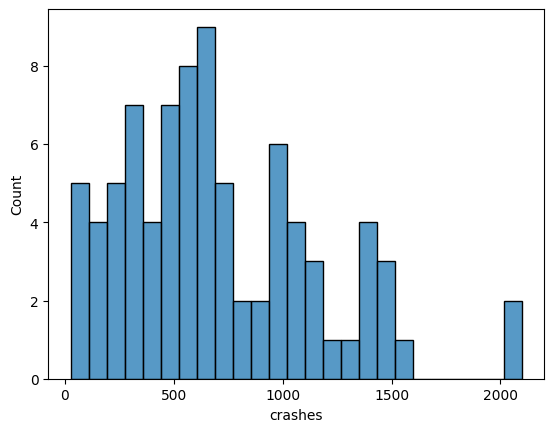

In [21]:
sns.histplot(df['crashes'], bins=25)

Text(0.5, 0, 'Log(Crashes)')

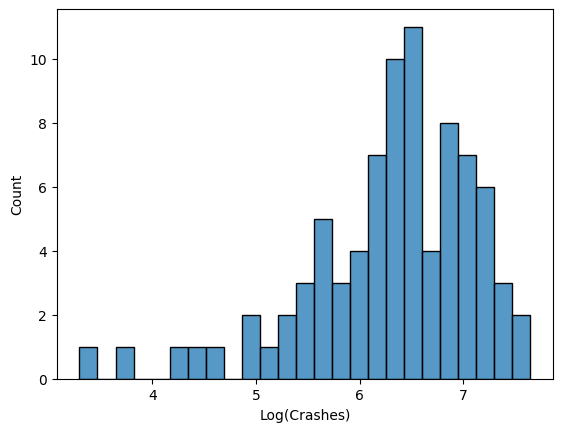

In [22]:
df['log_crash'] = np.log(df['crashes'])
sns.histplot(df['log_crash'], bins=25)
plt.xlabel("Log(Crashes)")

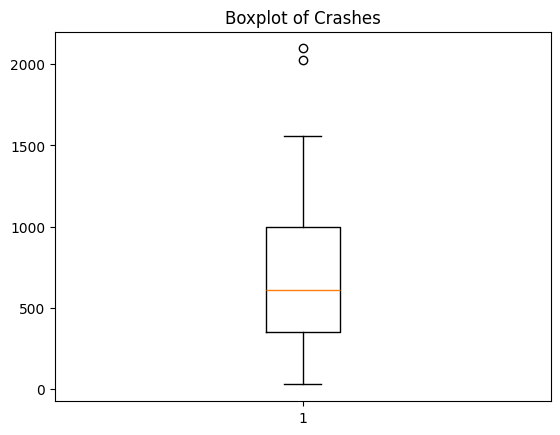

In [23]:
plt.boxplot(df['crashes'])
plt.title("Boxplot of Crashes")
plt.show()

In [24]:
df.sort_values(by='crashes')[['county', 'crashes']].head(5)

,county,crashes
41,Keweenaw,27
54,Menominee,40
47,Luce,74
26,Gogebic,84
1,Alger,107


<Axes: xlabel='county', ylabel='crashes'>

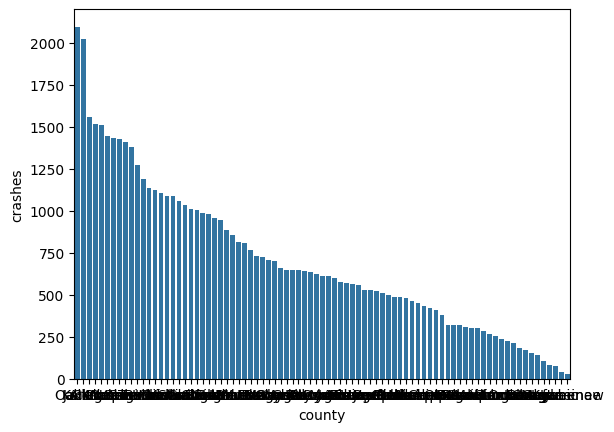

In [25]:
sns.barplot(x="county", y="crashes", data = df.sort_values(by='crashes', ascending=False)[['county', 'crashes']])

Text(0.5, 1.0, 'Top 15 Counties with Highest Crashes Count')

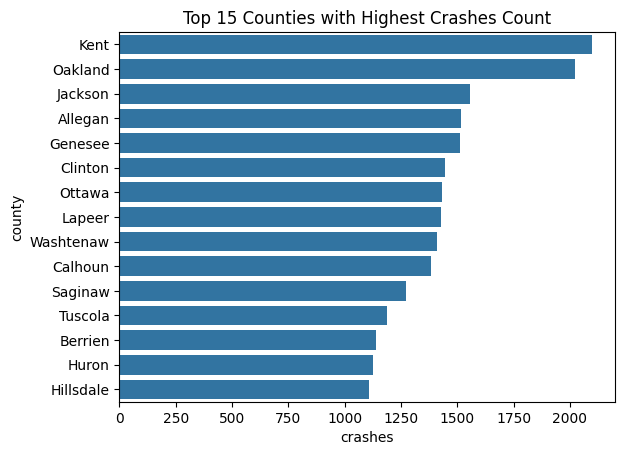

In [26]:
sns.barplot(y="county", x="crashes", data = df.sort_values(by='crashes', ascending=False)[['county', 'crashes']].head(15)
           )
plt.title("Top 15 Counties with Highest Crashes Count")

Kent and Oakland are 2 counties are the only 2 outliers

## 2. Features Exploration

### 2.1. Exposure

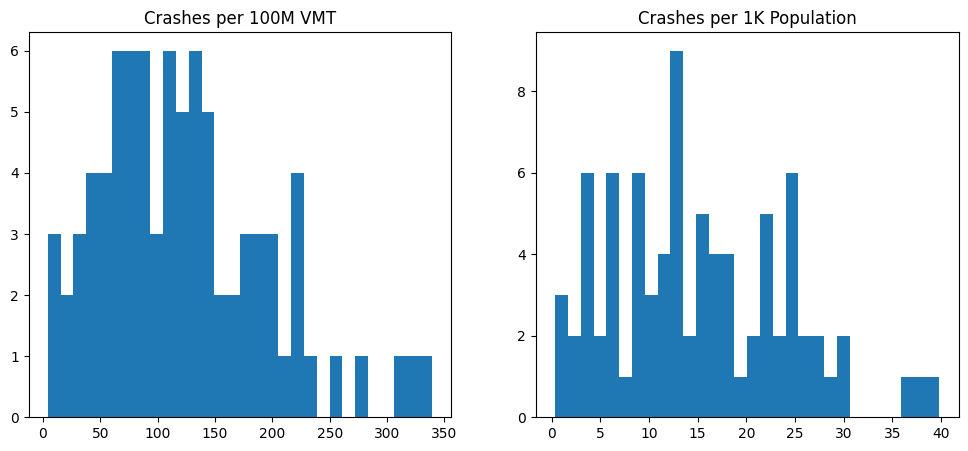

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(df['crashes_per_100m_vmt'], bins=30)
ax[0].set_title("Crashes per 100M VMT")

ax[1].hist(df['crashes_per_1k_pop'], bins=30)
ax[1].set_title("Crashes per 1K Population")

plt.show()

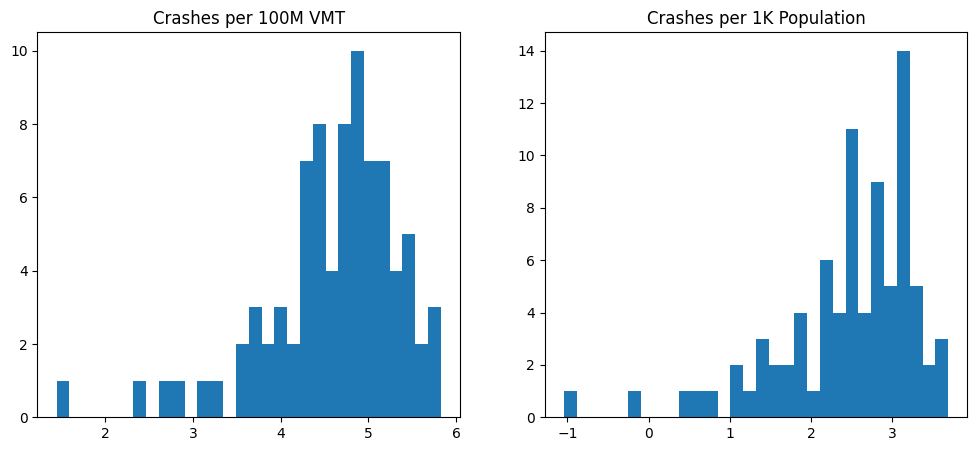

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(np.log(df['crashes_per_100m_vmt']), bins=30)
ax[0].set_title("Crashes per 100M VMT")

ax[1].hist(np.log(df['crashes_per_1k_pop']), bins=30)
ax[1].set_title("Crashes per 1K Population")

plt.show()

### 2.2. Peninsula and Ecoregion

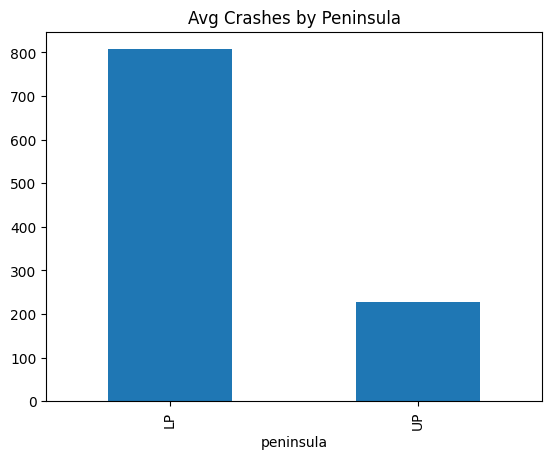

In [29]:
# Peninsula
df.groupby('peninsula')['crashes'].mean().plot(kind='bar')
plt.title("Avg Crashes by Peninsula")
plt.show()

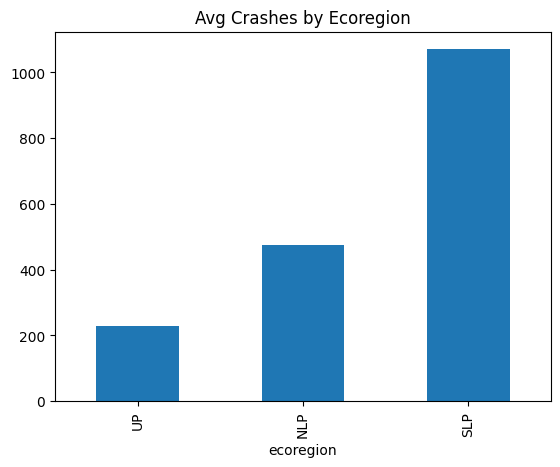

In [30]:
# Ecoregion
df.groupby('ecoregion')['crashes'].mean().sort_values().plot(kind='bar')
plt.title("Avg Crashes by Ecoregion")
plt.show()

### 2.3. Land Cover Effects

nlcd_43_pct   -0.569595
nlcd_42_pct   -0.556644
nlcd_52_pct   -0.537705
nlcd_41_pct   -0.499970
nlcd_90_pct   -0.425618
nlcd_71_pct   -0.330086
nlcd_11_pct   -0.201085
nlcd_31_pct   -0.149812
nlcd_95_pct   -0.134664
nlcd_24_pct    0.246186
nlcd_23_pct    0.256676
nlcd_82_pct    0.562284
nlcd_81_pct    0.574258
nlcd_22_pct    0.600117
nlcd_21_pct    0.727650
crashes        1.000000
Name: crashes, dtype: float64


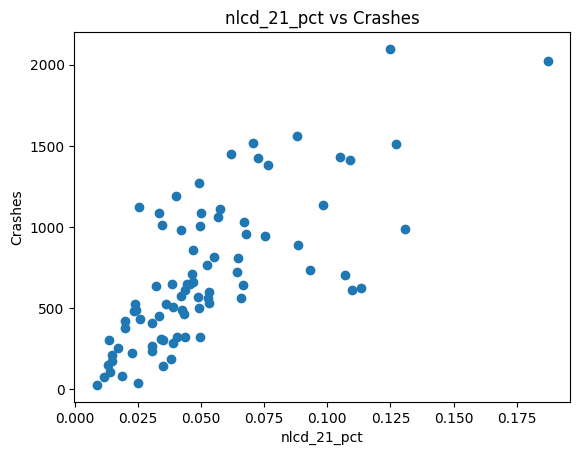

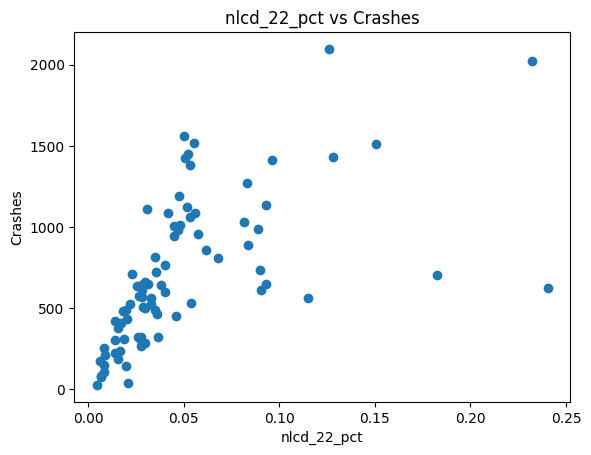

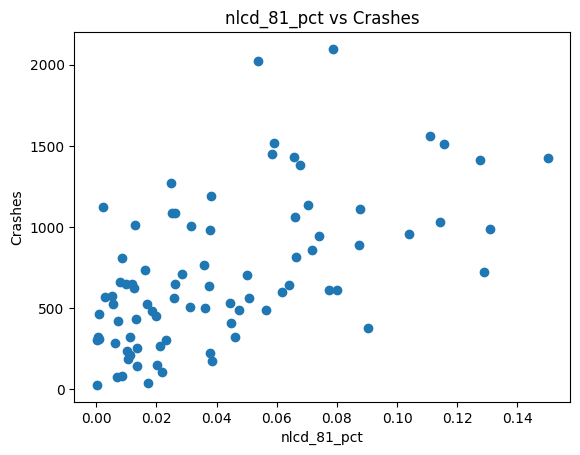

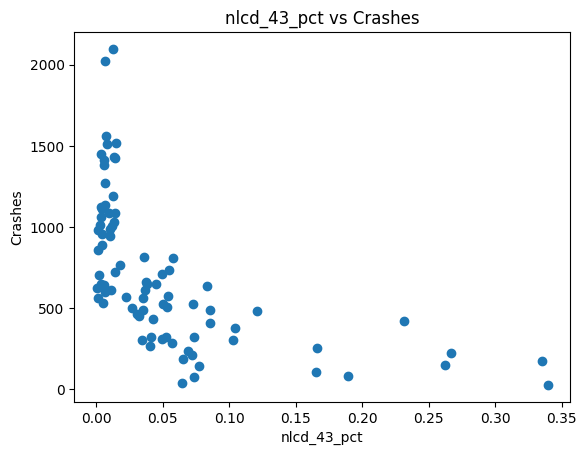

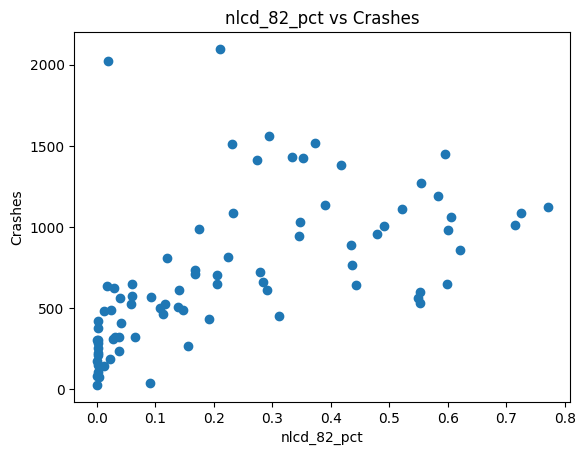

In [31]:
nlcd_cols = [col for col in df.columns if 'nlcd' in col]

# Correlation with crashes
corr_nlcd = df[nlcd_cols + ['crashes']].corr()['crashes'].sort_values()

print(corr_nlcd)

# visualize top relationships
top_vars = corr_nlcd.abs().sort_values(ascending=False).index[1:6]

for var in top_vars:
    plt.scatter(df[var], df['crashes'])
    plt.xlabel(var)
    plt.ylabel("Crashes")
    plt.title(f"{var} vs Crashes")
    plt.show()

### 2.3. Traffic

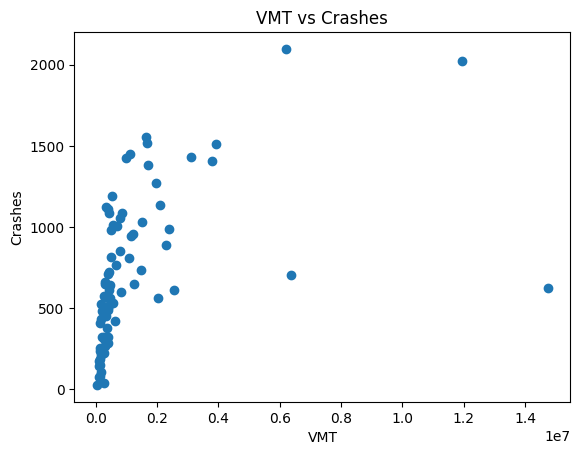

In [32]:
plt.scatter(df['vmt'], df['crashes'])
plt.xlabel("VMT")
plt.ylabel("Crashes")
plt.title("VMT vs Crashes")
plt.show()

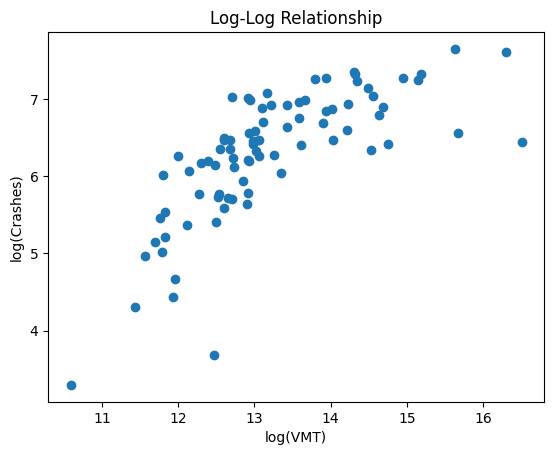

In [33]:
plt.scatter(np.log(df['vmt']), df['log_crash'])
plt.xlabel("log(VMT)")
plt.ylabel("log(Crashes)")
plt.title("Log-Log Relationship")
plt.show()


In [34]:
# Road Type
vmt_cols = ['vmt_ls1','vmt_ls2','vmt_ls3','vmt_ls4','vmt_ls5']

df[vmt_cols + ['crashes']].corr()['crashes']

vmt_ls1    0.461493
vmt_ls2    0.480880
vmt_ls3    0.566847
vmt_ls4    0.403202
vmt_ls5    0.289269
crashes    1.000000
Name: crashes, dtype: float64

VMT LS 3 (County local) has the highest correlation

### 2.4. Population and Density

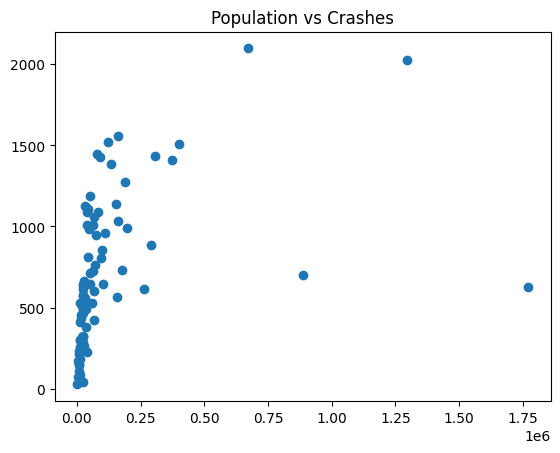

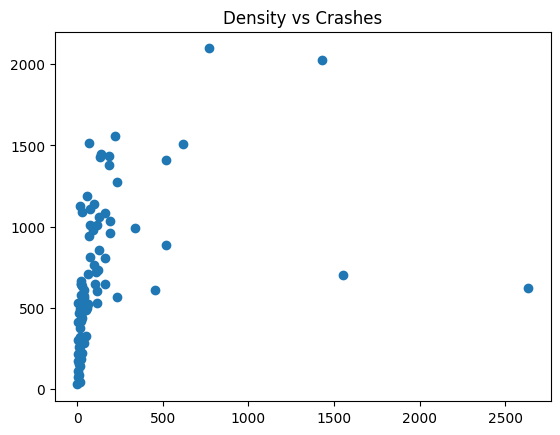

In [35]:
# create density
df['pop_density'] = df['population'] / df['area']

# population vs crashes
plt.scatter(df['population'], df['crashes'])
plt.title("Population vs Crashes")
plt.show()

# density vs crashes
plt.scatter(df['pop_density'], df['crashes'])
plt.title("Density vs Crashes")
plt.show()

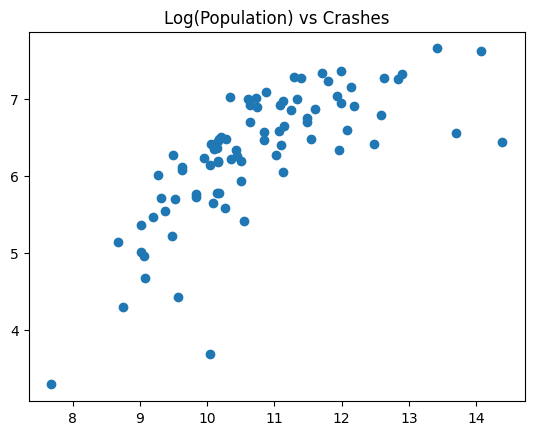

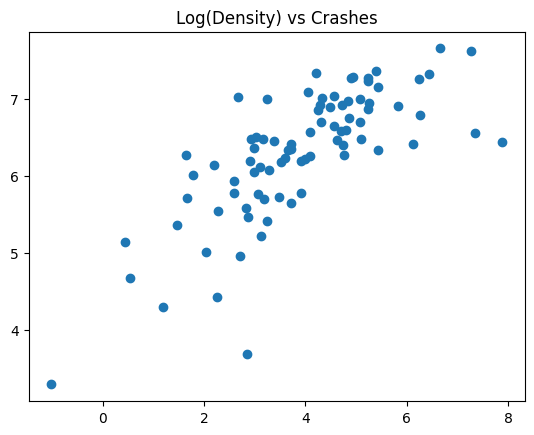

In [36]:
# population vs crashes
plt.scatter(np.log(df['population']), np.log(df['crashes']))
plt.title("Log(Population) vs Crashes")
plt.show()

# density vs crashes
plt.scatter(np.log(df['pop_density']), np.log(df['crashes']))
plt.title("Log(Density) vs Crashes")
plt.show()

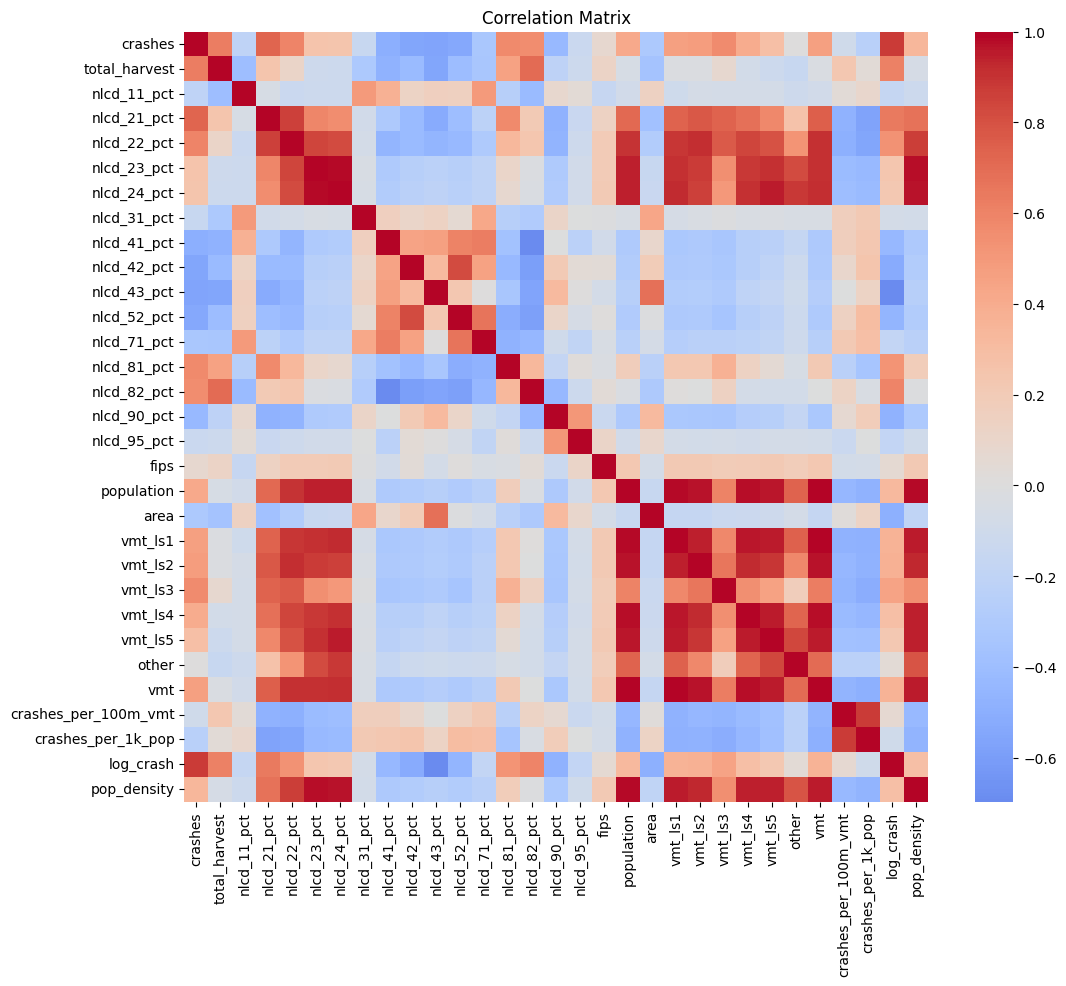

In [37]:
# select numeric variables
num_df = df.select_dtypes(include=np.number)

corr = num_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [38]:
# correlation with log_crash
corr_target = num_df.corr()['crashes'].sort_values(ascending=False)
print(corr_target.head(10))
print(corr_target.tail(10))

crashes          1.000000
log_crash        0.879659
nlcd_21_pct      0.727650
total_harvest    0.627783
nlcd_22_pct      0.600117
nlcd_81_pct      0.574258
vmt_ls3          0.566847
nlcd_82_pct      0.562284
vmt_ls2          0.480880
vmt              0.467476
Name: crashes, dtype: float64
nlcd_31_pct          -0.149812
nlcd_11_pct          -0.201085
crashes_per_1k_pop   -0.239398
area                 -0.316417
nlcd_71_pct          -0.330086
nlcd_90_pct          -0.425618
nlcd_41_pct          -0.499970
nlcd_52_pct          -0.537705
nlcd_42_pct          -0.556644
nlcd_43_pct          -0.569595
Name: crashes, dtype: float64


In [39]:
corr_target = num_df.corr()['log_crash'].sort_values(ascending=False)
print(corr_target.head(10))
print(corr_target.tail(10))

log_crash        1.000000
crashes          0.879659
nlcd_21_pct      0.644936
total_harvest    0.613791
nlcd_82_pct      0.596864
nlcd_22_pct      0.534165
nlcd_81_pct      0.526283
vmt_ls3          0.447333
vmt_ls2          0.366663
vmt_ls1          0.361320
Name: log_crash, dtype: float64
crashes_per_1k_pop   -0.093908
nlcd_11_pct          -0.165345
nlcd_95_pct          -0.180954
nlcd_71_pct          -0.181863
nlcd_41_pct          -0.441960
nlcd_52_pct          -0.460241
nlcd_90_pct          -0.476996
area                 -0.493633
nlcd_42_pct          -0.525305
nlcd_43_pct          -0.696303
Name: log_crash, dtype: float64


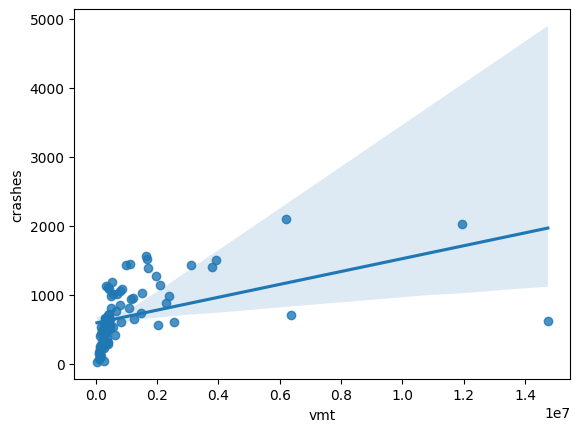

In [40]:
sns.regplot(x='vmt', y='crashes', data=df)
plt.show()

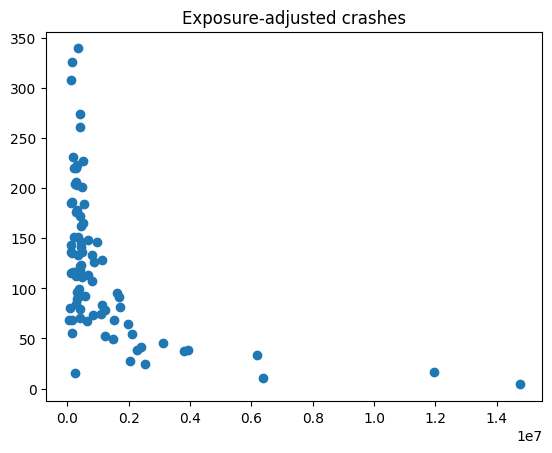

In [41]:
plt.scatter(df['vmt'], df['crashes_per_100m_vmt'])
plt.title("Exposure-adjusted crashes")
plt.show()

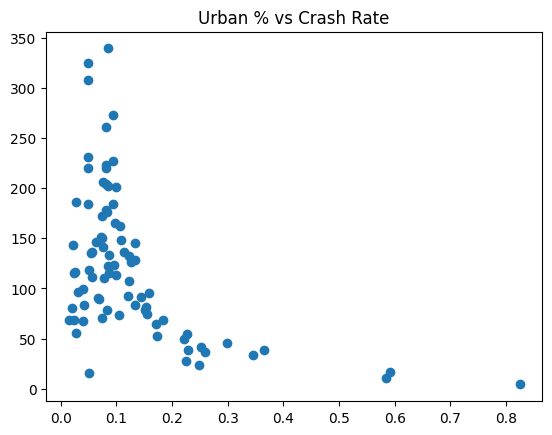

In [42]:
df['urban_pct'] = df[['nlcd_21_pct','nlcd_22_pct','nlcd_23_pct','nlcd_24_pct']].sum(axis=1)

plt.scatter(df['urban_pct'], df['crashes_per_100m_vmt'])
plt.title("Urban % vs Crash Rate")
plt.show()

# 3. Fit Linear Regression

In [43]:
df.columns

Index(['county', 'crashes', 'total_harvest', 'nlcd_11_pct', 'nlcd_21_pct',
       'nlcd_22_pct', 'nlcd_23_pct', 'nlcd_24_pct', 'nlcd_31_pct',
       'nlcd_41_pct', 'nlcd_42_pct', 'nlcd_43_pct', 'nlcd_52_pct',
       'nlcd_71_pct', 'nlcd_81_pct', 'nlcd_82_pct', 'nlcd_90_pct',
       'nlcd_95_pct', 'fips', 'population', 'area', 'peninsula', 'ecoregion',
       'area.1', 'vmt_ls1', 'vmt_ls2', 'vmt_ls3', 'vmt_ls4', 'vmt_ls5',
       'other', 'vmt', 'crashes_per_100m_vmt', 'crashes_per_1k_pop',
       'log_crash', 'pop_density', 'urban_pct'],
      dtype='object')

In [44]:
# try remove county
df_fit = df.drop(columns={'county'})

In [45]:
# keep only ecoregion (consistent with Alwaleed's EDA)
df_fit.dtypes

crashes                   int64
total_harvest             int64
nlcd_11_pct             float64
nlcd_21_pct             float64
nlcd_22_pct             float64
nlcd_23_pct             float64
nlcd_24_pct             float64
nlcd_31_pct             float64
nlcd_41_pct             float64
nlcd_42_pct             float64
nlcd_43_pct             float64
nlcd_52_pct             float64
nlcd_71_pct             float64
nlcd_81_pct             float64
nlcd_82_pct             float64
nlcd_90_pct             float64
nlcd_95_pct             float64
fips                      int64
population                int64
area                      int64
peninsula                object
ecoregion                object
area.1                   object
vmt_ls1                   int64
vmt_ls2                   int64
vmt_ls3                   int64
vmt_ls4                   int64
vmt_ls5                   int64
other                     int64
vmt                       int64
crashes_per_100m_vmt    float64
crashes_

In [46]:
df_fit = df_fit.drop(columns={'area.1', 'peninsula'})

In [47]:
df_fit['ecoregion'] = df_fit['ecoregion'].astype('category')
df_fit = pd.get_dummies(df_fit, columns=['ecoregion'], drop_first=True)

In [48]:
df_fit['ecoregion_SLP'] = df_fit['ecoregion_SLP'].astype('int')

In [49]:
df_fit['ecoregion_UP'] = df_fit['ecoregion_UP'].astype('int')

## 3.1. Fit Linear Regression for reference

In [50]:
def plot_regression_diagnostics(model, figsize=(8, 6)):
    fitted    = model.fittedvalues
    residuals = model.resid
    std_resid = (residuals - residuals.mean()) / residuals.std()

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle("Linear Regression Diagnostics", fontsize=14, fontweight="bold")

    # Residuals vs Fitted 
    ax1 = axes[0, 0]
    ax1.scatter(fitted, residuals, alpha=0.5, edgecolors="k", linewidths=0.4)
    ax1.axhline(0, color="red", linestyle="--", linewidth=1)
    smooth = lowess(residuals, fitted, frac=0.6)
    ax1.plot(smooth[:, 0], smooth[:, 1], color="red", linewidth=1)
    ax1.set_xlabel("Fitted values")
    ax1.set_ylabel("Residuals")
    ax1.set_title("Residuals vs Fitted")

    # Normal Q-Q 
    ax2 = axes[0, 1]
    qqplot(residuals, line="s", ax=ax2, alpha=0.5)
    ax2.set_title("Normal Q-Q")
    ax2.set_xlabel("Theoretical quantiles")
    ax2.set_ylabel("Sample quantiles")

    # Scale-Location
    ax3 = axes[1, 0]
    sqrt_std_resid = np.sqrt(np.abs(std_resid))
    ax3.scatter(fitted, sqrt_std_resid, alpha=0.5, edgecolors="k", linewidths=0.4)
    smooth2 = lowess(sqrt_std_resid, fitted, frac=0.6)
    ax3.plot(smooth2[:, 0], smooth2[:, 1], color="red", linewidth=1)
    ax3.set_xlabel("Fitted values")
    ax3.set_ylabel(r"$\sqrt{|\mathrm{Standardised\ residuals}|}$")
    ax3.set_title("Scale-Location")

    # Residuals vs Leverage
    ax4 = axes[1, 1]
    influence = model.get_influence()
    leverage  = influence.hat_matrix_diag
    cooks_d   = influence.cooks_distance[0]

    sc = ax4.scatter(leverage, std_resid, c=cooks_d,
                      cmap="RdYlGn_r", alpha=0.7,
                      edgecolors="k", linewidths=0.4)
    plt.colorbar(sc, ax=ax4, label="Cook's distance")
    ax4.axhline(0, color="grey", linestyle="--", linewidth=0.8)

    x_range = np.linspace(leverage.min() + 1e-6, leverage.max(), 200)
    p = model.df_model + 1
    for cd in [0.5, 1.0]:
        y_c = np.sqrt(cd * p * (1 - x_range) / x_range)
        ax4.plot(x_range,  y_c, color="red", linestyle="--", linewidth=0.8)
        ax4.plot(x_range, -y_c, color="red", linestyle="--", linewidth=0.8)

    ax4.set_xlabel("Leverage")
    ax4.set_ylabel("Standardised residuals")
    ax4.set_title("Residuals vs Leverage")

    plt.tight_layout()
    plt.show()
    return fig, axes

**STEP 1**: First, we fit a simple linear regression for our current dataset:

In [51]:
# y = Crash
X_lr = df_fit.drop(columns={'crashes', 'log_crash'}, axis=1)
y_lr = df_fit['crashes']
X_lr = sm.add_constant(X_lr)
lr_1 = sm.OLS(y_lr, X_lr).fit()
print(lr_1.summary())

                            OLS Regression Results                            
Dep. Variable:                crashes   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     17.21
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           8.46e-18
Time:                        16:32:58   Log-Likelihood:                -523.48
No. Observations:                  83   AIC:                             1111.
Df Residuals:                      51   BIC:                             1188.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  2.16e+05 

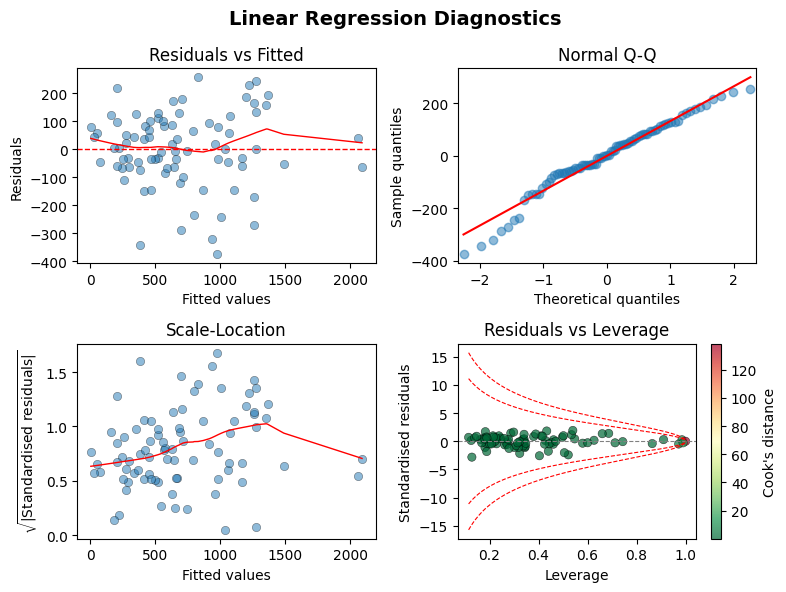

(<Figure size 800x600 with 5 Axes>,
 array([[<Axes: title={'center': 'Residuals vs Fitted'}, xlabel='Fitted values', ylabel='Residuals'>,
         <Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical quantiles', ylabel='Sample quantiles'>],
        [<Axes: title={'center': 'Scale-Location'}, xlabel='Fitted values', ylabel='$\\sqrt{|\\mathrm{Standardised\\ residuals}|}$'>,
         <Axes: title={'center': 'Residuals vs Leverage'}, xlabel='Leverage', ylabel='Standardised residuals'>]],
       dtype=object))

In [52]:
plot_regression_diagnostics(lr_1)

**Guide to Diagnostics:** 
* Residuals vs Fitted: checks linearity and equal variance => we want random scatter around the zero line with no funnel or curve, the red LOWESS line should be flat.
* Normal Q-Q: checks whether residuals are normally distributed => we want points to fall tightly along the diagonal reference line, heavy tails or S-curves indicate non-normality.
* Scale-Location: a purer homoscedasticity check (spreading variance) => the red trend line should be roughly horizontal, an upward slope means variance grows with fitted values.
* Residuals vs Leverage: spots influential outliers. Points beyond the dashed Cook's distance contours (0.5 and 1.0) are worth investigating because they pull the regression line disproportionately (Color intensity also encodes Cook's D).

==> The model has high adj R-squared but diagnostics shows non-normality pattern in residuals (Q-Q) and slightly high variance in residuals.

Let's see if log(Crash) improve the model:

In [53]:
# y = Log Crash
X_lr = df_fit.drop(columns={'crashes', 'log_crash'}, axis=1)
y_lr = df_fit['log_crash']
X_lr = sm.add_constant(X_lr)
lr_2 = sm.OLS(y_lr, X_lr).fit()
print(lr_2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_crash   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     8.483
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.97e-11
Time:                        16:33:15   Log-Likelihood:                -27.213
No. Observations:                  83   AIC:                             118.4
Df Residuals:                      51   BIC:                             195.8
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2287.9484 

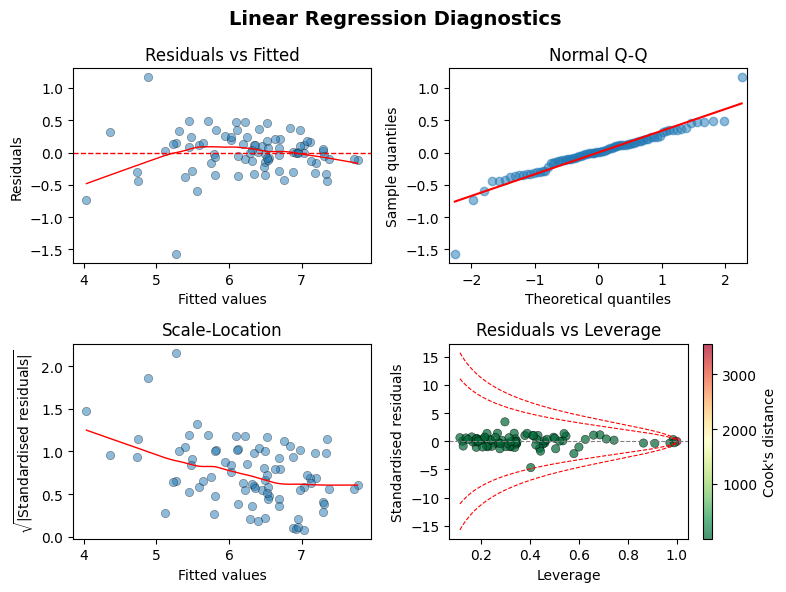

(<Figure size 800x600 with 5 Axes>,
 array([[<Axes: title={'center': 'Residuals vs Fitted'}, xlabel='Fitted values', ylabel='Residuals'>,
         <Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical quantiles', ylabel='Sample quantiles'>],
        [<Axes: title={'center': 'Scale-Location'}, xlabel='Fitted values', ylabel='$\\sqrt{|\\mathrm{Standardised\\ residuals}|}$'>,
         <Axes: title={'center': 'Residuals vs Leverage'}, xlabel='Leverage', ylabel='Standardised residuals'>]],
       dtype=object))

In [54]:
plot_regression_diagnostics(lr_2)

In [55]:
lr_1.mse_resid

np.float64(28653.52632578949)

In [56]:
lr_2.mse_resid

np.float64(0.18357424086605997)

In [57]:
len(df_fit.columns)

34

In [58]:
print(lr_2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_crash   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     8.483
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.97e-11
Time:                        16:33:24   Log-Likelihood:                -27.213
No. Observations:                  83   AIC:                             118.4
Df Residuals:                      51   BIC:                             195.8
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2287.9484 

=> Conclusion: Although the linear regression model with log(Crash) yield a higher R-squared and adj R-squared than the previous model with y = Crash, however, the model with log(Crash) shows a better pattern in model diagnostics. The linearity relationship is better (fitted vs residuals is more random), and variance in scale-location is less volatile. Although there is a problem of outliers in the model.

**STEP 2**: From EDA, we found several variables are skewed. Let's try log transform those variables:

In [59]:
df_fit['log_vmt'] = np.log(df_fit['vmt'])
df_fit['log_crashes_per_100m_vmt'] = np.log(df_fit['crashes_per_100m_vmt'])
df_fit['log_crashes_per_1k_pop'] = np.log(df_fit['crashes_per_1k_pop'])
df_fit['log_population'] = np.log(df_fit['population'])
df_fit['log_pop_density'] = np.log(df_fit['pop_density'])

In [60]:
X_lr = df_fit.drop(columns={'crashes', 'log_crash', 'vmt', 'crashes_per_100m_vmt', 
                           'crashes_per_1k_pop', 'population', 'pop_density'}, axis=1)
y_lr = df_fit['log_crash']
X_lr = sm.add_constant(X_lr)
lr_3 = sm.OLS(y_lr, X_lr).fit()
print(lr_3.summary())

                            OLS Regression Results                            
Dep. Variable:              log_crash   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.338e+20
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:33:31   Log-Likelihood:                 1797.8
No. Observations:                  83   AIC:                            -3534.
Df Residuals:                      52   BIC:                            -3459.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

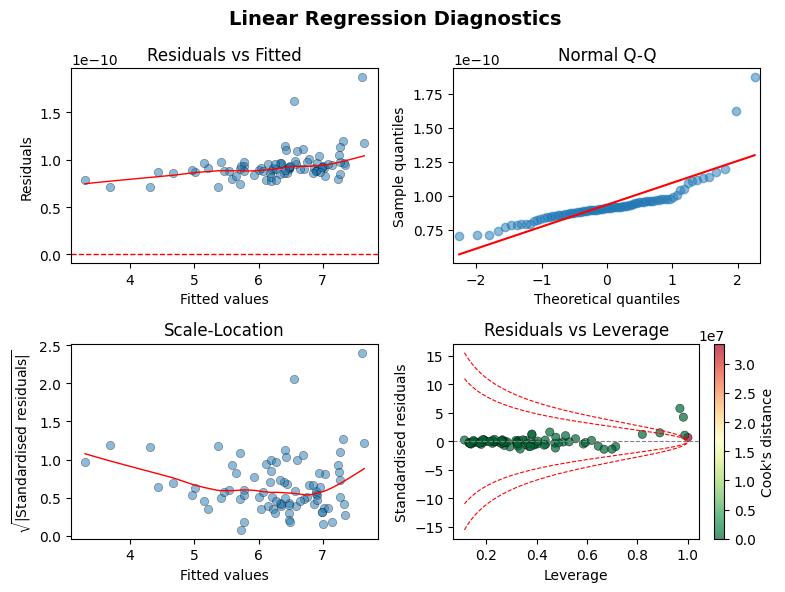

(<Figure size 800x600 with 5 Axes>,
 array([[<Axes: title={'center': 'Residuals vs Fitted'}, xlabel='Fitted values', ylabel='Residuals'>,
         <Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical quantiles', ylabel='Sample quantiles'>],
        [<Axes: title={'center': 'Scale-Location'}, xlabel='Fitted values', ylabel='$\\sqrt{|\\mathrm{Standardised\\ residuals}|}$'>,
         <Axes: title={'center': 'Residuals vs Leverage'}, xlabel='Leverage', ylabel='Standardised residuals'>]],
       dtype=object))

In [61]:
plot_regression_diagnostics(lr_3)

The data is relatively small, therefore, overfitting is inevitable. Even though the model have high accuracy, the coefficients are unstable, and inherent problems of the dataset (non-normal residual, heteroskedascity, nonlinearity and influential points) cannot be fixed.

We will improve this by using Bootstrap + Forward Stepwise Cross Validation to choose the final model for linear regression.

## 3.2. Fit Linear Regression with Bootstrap + Cross Validation

In [62]:
def bootstrap_df(df, n_samples=None):
    if n_samples is None:
        n_samples = len(df)
    return df.sample(n=n_samples, replace=True, random_state=None)


In [63]:
def stepwise_selection(X, y, max_features=None, cv_folds=5):
    if max_features is None:
        max_features = X.shape[1]
    
    remaining = list(X.columns)
    selected = []
    best_mse = np.inf

    for _ in range(max_features):
        mse_with_candidates = []
        for candidate in remaining:
            features = selected + [candidate]
            X_subset = sm.add_constant(X[features])
            
            # CV
            kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
            mse_folds = []
            for train_idx, test_idx in kf.split(X_subset):
                X_train, X_test = X_subset.iloc[train_idx], X_subset.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
                
                model = sm.OLS(y_train, X_train).fit()
                y_pred = model.predict(X_test)
                mse_folds.append(mean_squared_error(y_test, y_pred))
            mse_avg = np.mean(mse_folds)
            mse_with_candidates.append((mse_avg, candidate))
        
        mse_with_candidates.sort()
        best_new_mse, best_candidate = mse_with_candidates[0]
        if best_new_mse < best_mse:
            selected.append(best_candidate)
            remaining.remove(best_candidate)
            best_mse = best_new_mse
        else:
            break

    return selected, best_mse

In [64]:
def bootstrap_stepwise_diagnostics(df, target="log_crash", n_bootstrap=100):
    mse_list = []
    r2_list = []
    selected_features_list = []

    for i in range(n_bootstrap):
        df_boot = bootstrap_df(df)
        X = df_boot.drop(columns={'crashes', 'log_crash'}, axis=1)
        y = df_boot[target]

        # Stepwise selection
        selected_features, mse = stepwise_selection(X, y, cv_folds=5)
        selected_features_list.append(selected_features)

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X[selected_features], y, test_size=0.2, random_state=1
        )
        X_train_sm = sm.add_constant(X_train)
        X_test_sm  = sm.add_constant(X_test)

        # Fit model
        model = sm.OLS(y_train, X_train_sm).fit()

        # Test set evaluation
        y_pred = model.predict(X_test_sm)
        mse_test = mean_squared_error(y_test, y_pred)
        r2_test = model.rsquared 

        mse_list.append(mse_test)
        r2_list.append(r2_test)

        # Safe coefficient storage
        for col in df_fit.drop(columns=['crashes']).columns:
            if col in model.params:
                coef_dict[col].append(model.params[col])
            else:
                coef_dict[col].append(np.nan)

    print("Average Test MSE:", np.mean(mse_list))
    print("Average R-squared (train):", np.mean(r2_list))

    return mse_list, r2_list, selected_features_list

In [65]:
coef_dict = {col: [] for col in df_fit.drop(columns=['crashes']).columns}

In [66]:
df_fit_boot = df_fit.drop(columns={'log_vmt', 'log_crashes_per_100m_vmt','log_crashes_per_1k_pop', 
                                  'log_population', 'log_pop_density', 'crashes_per_1k_pop', 'crashes_per_100m_vmt'})
mse_list, r2_list, selected_features_list = bootstrap_stepwise_diagnostics(df_fit_boot, target="log_crash",  n_bootstrap=100)

Average Test MSE: 0.18692288447443062
Average R-squared (train): 0.809201154071046


In [67]:
coef_dict_agg = pd.DataFrame(coef_dict)
coef_dict_agg['bootstrap_iter'] = np.arange(1, len(coef_dict_agg) + 1)
cols = ['bootstrap_iter'] + [c for c in coef_dict_agg.columns if c != 'bootstrap_iter']
coef_dict_agg = coef_dict_agg[cols]

In [68]:
num_features_per_bootstrap = [len(features) for features in selected_features_list]
print("Min features:", np.min(num_features_per_bootstrap))
print("Max features:", np.max(num_features_per_bootstrap))
print("Average features:", np.mean(num_features_per_bootstrap))

Min features: 4
Max features: 17
Average features: 9.16


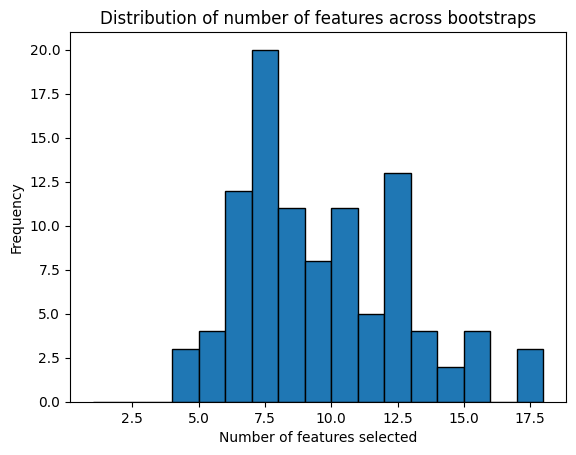

In [69]:
plt.hist(num_features_per_bootstrap, bins=range(1, max(num_features_per_bootstrap)+2), edgecolor='k')
plt.xlabel("Number of features selected")
plt.ylabel("Frequency")
plt.title("Distribution of number of features across bootstraps")
plt.show()

In [70]:
non_nan_counts = coef_dict_agg.drop(columns=['bootstrap_iter']).count().reset_index().rename(columns={0:'bootstrap_count'})
non_nan_counts = non_nan_counts.sort_values(by='bootstrap_count', ascending=False)
top_features =  non_nan_counts.head(10)
top_features

,index,bootstrap_count
31,ecoregion_SLP,63
12,nlcd_81_pct,60
8,nlcd_42_pct,60
0,total_harvest,58
11,nlcd_71_pct,55
6,nlcd_31_pct,54
32,ecoregion_UP,53
2,nlcd_21_pct,53
9,nlcd_43_pct,47
18,area,33


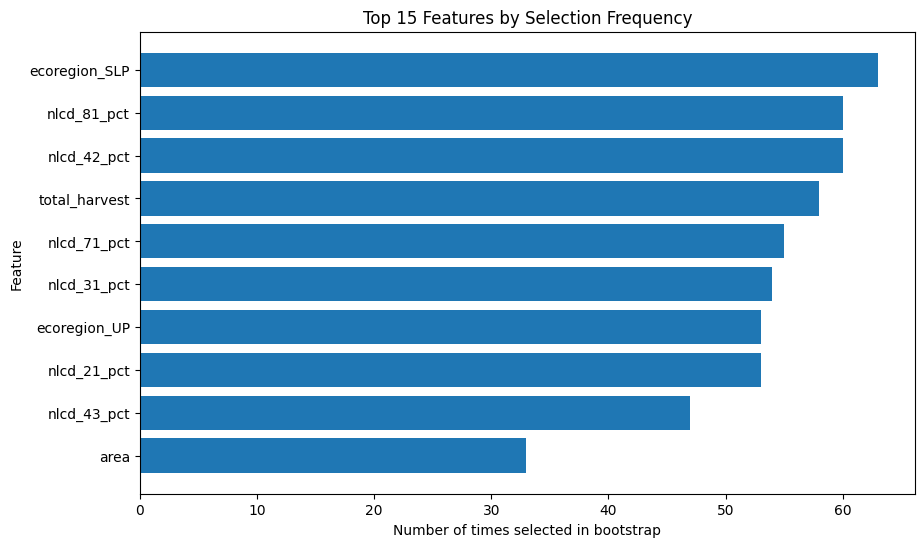

In [71]:
plt.figure(figsize=(10, 6))
plt.barh(top_features['index'], top_features['bootstrap_count'])
plt.xlabel("Number of times selected in bootstrap")
plt.ylabel("Feature")
plt.title("Top 15 Features by Selection Frequency")
plt.gca().invert_yaxis() 
plt.show()

In [72]:
def bootstrap_summarize(coef_df, iteration_col='bootstrap_iter'):
    
    coef_summary = coef_df.drop(columns=[iteration_col], errors='ignore')
    # Mean coefficient
    mean_coef = coef_summary.mean()
    # 95% confidence intervals
    lower_ci = coef_summary.quantile(0.025)
    upper_ci = coef_summary.quantile(0.975)


    bootstrap_summary = pd.DataFrame({
        'variable': coef_summary.columns,
        'mean_coeff': mean_coef.values,
        'lower_ci': lower_ci.values,
        'upper_ci': upper_ci.values})

    bootstrap_summary = bootstrap_summary.sort_values(by='mean_coeff', key=np.abs, ascending=False).reset_index(drop=True)

    return bootstrap_summary

In [73]:
bootstrap_summary = bootstrap_summarize(coef_dict_agg)
bootstrap_summary[~bootstrap_summary['mean_coeff'].isna()]

,variable,mean_coeff,lower_ci,upper_ci
0,nlcd_31_pct,3.260901e+01,-8.326683e+00,7.967956e+01
1,nlcd_24_pct,1.091496e+01,-1.584011e+02,1.402343e+02
2,nlcd_95_pct,-8.092244e+00,-2.796043e+01,1.434227e+01
3,nlcd_23_pct,-6.769450e+00,-4.997140e+01,2.832868e+01
4,nlcd_22_pct,5.774150e+00,-1.105491e+01,2.987025e+01
5,nlcd_52_pct,-5.685217e+00,-1.774182e+01,4.491629e+00
6,nlcd_81_pct,5.175992e+00,1.164552e+00,8.912910e+00
7,nlcd_71_pct,4.983595e+00,6.184238e-01,8.958524e+00
8,nlcd_21_pct,3.655094e+00,-1.648105e+01,1.394581e+01
9,nlcd_42_pct,-2.789630e+00,-5.069066e+00,3.740646e-01


# 4. Conclusion for Linear Regression

## 4.2. Fit simple LR on dataset

(1) Choosing y = crash or y = log(crash) 
  * Although the linear regression model with log(Crash) yield a higher R-squared and adj R-squared than the previous model with y = Crash, however, the model with log(Crash) reduce MSE from 28000 to 0.18, indicating model without log_transformation on y has a bad performance. 
  * Model Diagnostics is also better: the linearity relationship is alsobetter (fitted vs residuals is more random), and variance in scale-location is less volatile.
  * However, there is a still problem of outliers, linearity and high residual variance assumption.

(2) Log transform on features 
  * When trying log transformation for `vmt`, `crashes_per_100m_vmt`, `crashes_per_1k_pop`, `population`, and `pop_density` (these features are chosen from EDA result), model becomes overfitted, showing signs of unstable coefficients and non-linearity assumption. => log_transform on features may not be a good choice.

Conclusion:  This dataset is small, therefore simple linear regression estimates are unstable and overestimate the performance of the model. There are also signs of multicollinearity and nonlinearity assumption that makes simple linear regression result unrealiable for the prblem.
We will improve it with bootstrap and model selection (stepwise + cross validation on test mse), while continue using log(Crash) as output variable.

## 4.3. Fit LR with bootstrap and stepwise model selection
* Setting
  * 100 bootstraps
  * 5-fold CV stepwise
  * To avoid overfitting, we also try removing crashes_per_100m_vmt and crashes_per_1k_pop because these metrics are calculated by output.
* Result:
  * Average features chosen in 100 bootstrap is 9 (min = 4, max = 17). Most bootstrap select 7 features.
  * Average test MSE = 0.18
  * Train test yields 80.9% R-squared

* Brief notes for interpretation: nlcd_81_pct, ecoregion_SLP, nlcd_42_pct, and total_harvest are the 4 most stable features (show up the most in 100 bootstraps). The most influential features to the number of crashes are: land_cover, especially in: barren land (31_pct, positive), high intensity area (24_pct, positive), welands (95_pct, negative), ecoregion, and pop density.

Indication for policy makers: Deer Collision prevention initiatives should be customized by depends on the region of the county, and retaining crash rate per vehicle miles can be used as an key performance metrics for the policy, as well as 

* Notes about Bootstrap: Bootstrap only helps with unstability in features and overfitting, it cannot inherently fixes inherent issues in linear regression diagnostics. Using Bootstrap for LR helps us to find the most stable features in linearity assumption, not change the assumption itself. Therefore we'll need to explore some other models.



## 4.4. Key Results
* Simple Linear Regression with log-y:
  * MSE = 0.18
  * Number of features 39 (all features)
  * Problems: Overfitting + Unstable Coefficients

* Fit LR with bootstrap and stepwise model selection
  * MSE = 0.18
  * Number of features: 7
  * Problems: Still overfitting & underlying LR diagnostics issues.

## 4.4. What's to expect in next models
  * These models will not have linearity assumption -> expect the reality to be better
  * There are still risks of overfitting due to small dataset
  * A different ways of feature importance measurement: instead of using coefficients, trees use splot
  * Bootstrap is already built-in in tree models